# Day 3 — Exploratory Data Analysis (EDA) — Titanic Dataset

This notebook performs exploratory data analysis on the Titanic dataset to understand distributions, relationships, patterns, outliers, and survival trends.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load Titanic dataset
df = pd.read_csv("titanic.csv")

# Standardize column names
df.columns = df.columns.str.strip().str.lower()

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1309, 11)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


## 1. Dataset Structure and Data Quality

In [3]:
print("Rows and columns:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Rows and columns: (1309, 11)

Data types:


pclass        int64
name            str
sex             str
age         float64
sibsp         int64
parch         int64
ticket          str
fare        float64
cabin           str
embarked        str
survived      int64
dtype: object


Missing values:


cabin       1014
age          263
embarked       2
fare           1
sex            0
pclass         0
name           0
ticket         0
parch          0
sibsp          0
survived       0
dtype: int64


Duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pclass,1309.0,NaN,NaN,NaN,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
name,1309,1307,"Connolly, Miss. Kate",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1309,2,male,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1046.0,NaN,NaN,NaN,29.881135,14.4135,0.1667,21.0,28.0,39.0,80.0
sibsp,1309.0,NaN,NaN,NaN,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
parch,1309.0,NaN,NaN,NaN,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
ticket,1309,929,CA. 2343,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fare,1308.0,NaN,NaN,NaN,33.295479,51.758668,0.0,7.8958,14.4542,31.275,512.3292
cabin,295,186,C23 C25 C27,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
embarked,1307,3,S,914,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Summary Statistics

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_cols].describe().T)

print("Overall survival rate:",
      round(df["survived"].mean() * 100, 2), "%")


,count,mean,std,min,25%,50%,75%,max
pclass,1309.0,2.294882,0.837836,1.0000,2.0000,3.0000,3.000,3.0000
age,1046.0,29.881135,14.413500,0.1667,21.0000,28.0000,39.000,80.0000
sibsp,1309.0,0.498854,1.041658,0.0000,0.0000,0.0000,1.000,8.0000
parch,1309.0,0.385027,0.865560,0.0000,0.0000,0.0000,0.000,9.0000
fare,1308.0,33.295479,51.758668,0.0000,7.8958,14.4542,31.275,512.3292
survived,1309.0,0.381971,0.486055,0.0000,0.0000,0.0000,1.000,1.0000


Overall survival rate: 38.2 %


## 3. Visualization 1 — Survival Distribution

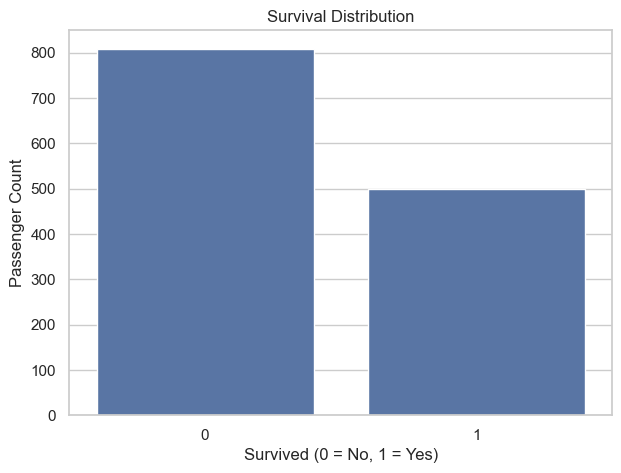

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="survived")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger Count")
plt.show()


## 4. Visualization 2 — Passenger Class Distribution

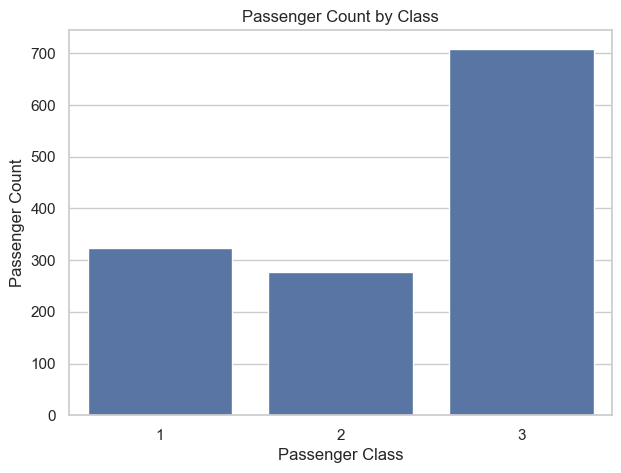

In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="pclass")
plt.title("Passenger Count by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()


## 5. Visualization 3 — Age Distribution

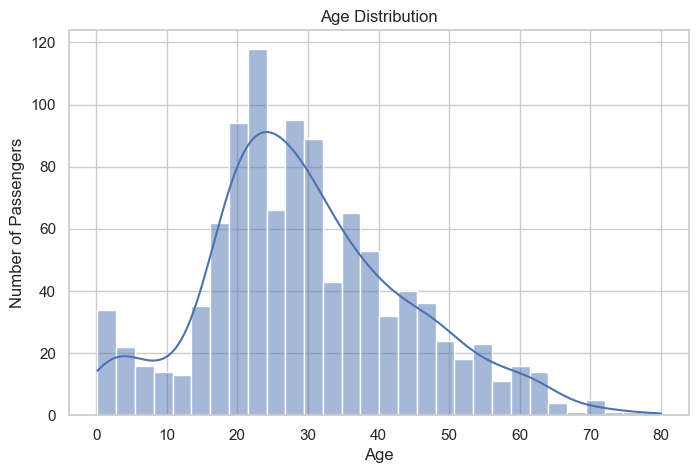

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


## 6. Visualization 4 — Fare Distribution and Outliers

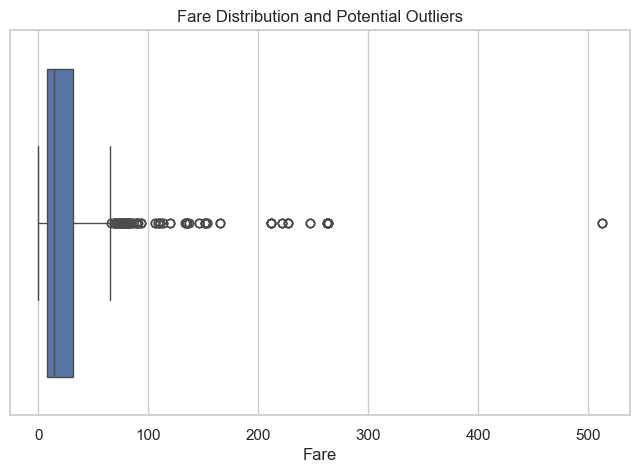

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fare")
plt.title("Fare Distribution and Potential Outliers")
plt.xlabel("Fare")
plt.show()


## 7. Visualization 5 — Survival Rate by Passenger Class

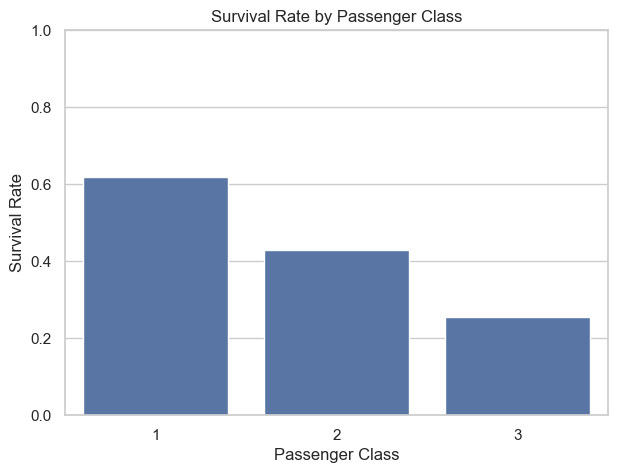

,pclass,survived,survival_rate_percent
0,1,0.619195,61.92
1,2,0.429603,42.96
2,3,0.255289,25.53


In [9]:
class_survival = df.groupby("pclass", as_index=False)["survived"].mean()

plt.figure(figsize=(7, 5))
sns.barplot(data=class_survival, x="pclass", y="survived")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

display(class_survival.assign(survival_rate_percent=
                             (class_survival["survived"] * 100).round(2)))


## 8. Visualization 6 — Survival Rate by Gender

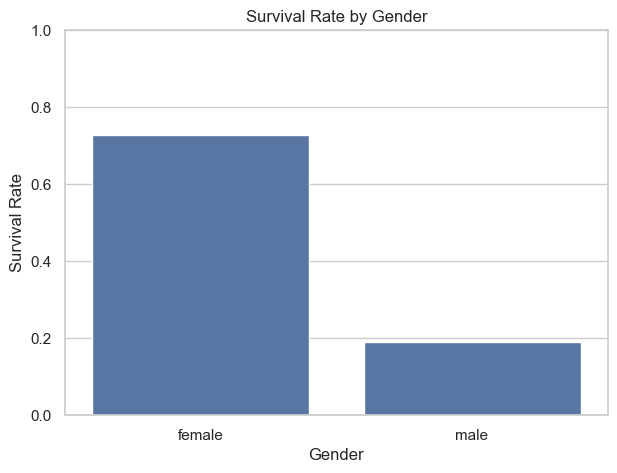

,sex,survived,survival_rate_percent
0,female,0.727468,72.75
1,male,0.190985,19.10


In [10]:
gender_survival = df.groupby("sex", as_index=False)["survived"].mean()

plt.figure(figsize=(7, 5))
sns.barplot(data=gender_survival, x="sex", y="survived")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

display(gender_survival.assign(survival_rate_percent=
                               (gender_survival["survived"] * 100).round(2)))


## 9. Visualization 7 — Age by Survival Status

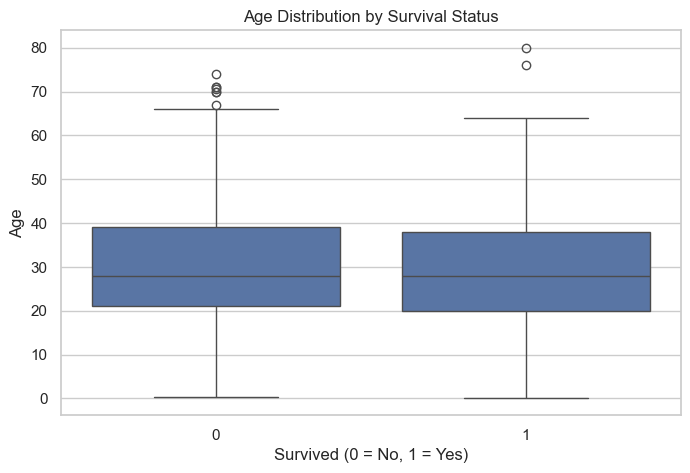

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()


## 10. Visualization 8 — Correlation Heatmap

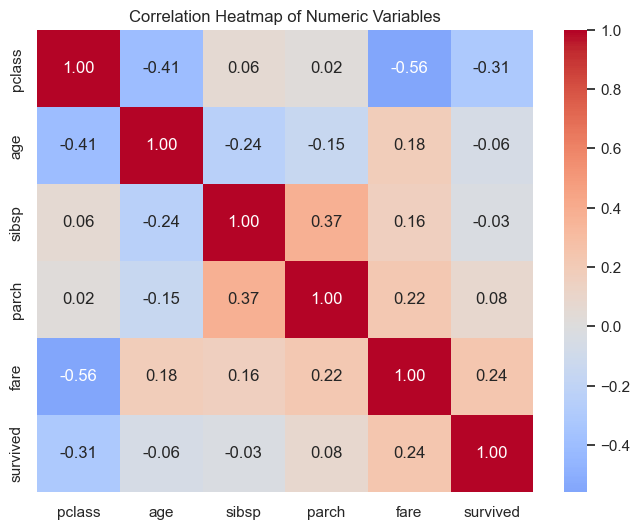

In [12]:
corr_cols = [c for c in ["pclass", "age", "sibsp", "parch", "fare", "survived"]
             if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


## 11. Relationship Analysis

In [13]:
# Survival rate by class and gender
class_gender = (
    df.groupby(["pclass", "sex"])["survived"]
      .agg(["count", "mean"])
      .reset_index()
      .rename(columns={"count": "passengers", "mean": "survival_rate"})
)

class_gender["survival_rate_percent"] = (class_gender["survival_rate"] * 100).round(2)

display(class_gender)

# Family size
df["family_size"] = df["sibsp"] + df["parch"] + 1

family_survival = (
    df.groupby("family_size")["survived"]
      .agg(["count", "mean"])
      .reset_index()
      .rename(columns={"count": "passengers", "mean": "survival_rate"})
)

family_survival["survival_rate_percent"] = (
    family_survival["survival_rate"] * 100
).round(2)

display(family_survival.head(15))


,pclass,sex,passengers,survival_rate,survival_rate_percent
0,1,female,144,0.965278,96.53
1,1,male,179,0.340782,34.08
2,2,female,106,0.886792,88.68
3,2,male,171,0.146199,14.62
4,3,female,216,0.490741,49.07
5,3,male,493,0.152130,15.21


,family_size,passengers,survival_rate,survival_rate_percent
0,1,790,0.302532,30.25
1,2,235,0.536170,53.62
2,3,159,0.566038,56.60
3,4,43,0.697674,69.77
4,5,22,0.272727,27.27
5,6,25,0.200000,20.00
6,7,16,0.250000,25.00
7,8,8,0.000000,0.00
8,11,11,0.000000,0.00


## 12. Top 5 Business / Analytical Insights

In [14]:
# Calculate values used for the insights
overall_rate = df["survived"].mean()
class_rates = df.groupby("pclass")["survived"].mean()
gender_rates = df.groupby("sex")["survived"].mean()
median_fare = df["fare"].median()
age_median = df["age"].median()

highest_class = class_rates.idxmax()
lowest_class = class_rates.idxmin()
highest_gender = gender_rates.idxmax()

print("1. Overall survival rate:",
      round(overall_rate * 100, 2), "%")

print("2. Passenger class is strongly associated with survival:",
      f"Class {highest_class} has the highest survival rate while Class {lowest_class} has the lowest.")

print("3. Gender is strongly associated with survival:",
      f"{highest_gender} passengers have the highest survival rate among the recorded gender groups.")

print("4. Fare is highly variable:",
      f"the median fare is {median_fare:.2f}, and the fare boxplot shows potential high-value outliers.")

print("5. Age varies considerably:",
      f"the median passenger age is {age_median:.1f}; age distributions differ between survivors and non-survivors.")


1. Overall survival rate: 38.2 %
2. Passenger class is strongly associated with survival: Class 1 has the highest survival rate while Class 3 has the lowest.
3. Gender is strongly associated with survival: female passengers have the highest survival rate among the recorded gender groups.
4. Fare is highly variable: the median fare is 14.45, and the fare boxplot shows potential high-value outliers.
5. Age varies considerably: the median passenger age is 28.0; age distributions differ between survivors and non-survivors.


## Conclusion

The EDA shows that passenger class and gender are important variables associated with Titanic survival. Fare is right-skewed and contains potential high-value outliers. Age has missing values and a wide distribution, while family-related variables can also be explored through `sibsp`, `parch`, and the derived `family_size` feature.

EDA helps identify these patterns before statistical modeling or machine-learning work begins.


## Interview Questions

### 1. How do you distinguish a genuine outlier from a data-entry error?

First inspect the value in context using distributions, boxplots, domain knowledge, and related columns. A value should not be removed just because it is unusual. If it is plausible in the real-world context, it may be a genuine outlier; if it violates valid ranges or is inconsistent with the source, it may be a data-entry error.

### 2. Why is EDA important before modeling?

EDA helps understand the data structure, distributions, missing values, outliers, relationships, and potential biases. It can reveal data-quality problems and guide feature engineering and model selection before training a model.

### 3. What does a strong correlation between two variables indicate?

A strong correlation indicates that two numeric variables have a strong linear relationship. Positive correlation means they tend to increase together, while negative correlation means one tends to decrease as the other increases. Correlation does **not** by itself prove causation.
